In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "countries of the world.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fernandol/countries-of-the-world",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:            Country                               Region  Population  \
0     Afghanistan         ASIA (EX. NEAR EAST)             31056997   
1         Albania   EASTERN EUROPE                          3581655   
2         Algeria   NORTHERN AFRICA                        32930091   
3  American Samoa   OCEANIA                                   57794   
4         Andorra   WESTERN EUROPE                            71201   

   Area (sq. mi.) Pop. Density (per sq. mi.) Coastline (coast/area ratio)  \
0          647500                       48,0                         0,00   
1           28748                      124,6                         1,26   
2         2381740                       13,8                         0,04   
3             199                      290,4                        58,29   
4             468                      152,1                         0,00   

  Net migration Infant mortality (per 1000 births)  GDP ($ per capita)  \
0         23,06    

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [3]:
data = df.copy()

# usuniecie kolumn nienumeryczne
data = data.drop(columns=["Country", "Region"])

# zamiana przecinków w liczbach i konwersja na float
for col in data.columns:
    data[col] = data[col].astype(str).str.replace(",", ".")
    data[col] = pd.to_numeric(data[col], errors="coerce")

# usuniecie brakow
data = data.dropna()

print(data.head())
print(data.shape)

   Population  Area (sq. mi.)  Pop. Density (per sq. mi.)  \
0    31056997          647500                        48.0   
1     3581655           28748                       124.6   
2    32930091         2381740                        13.8   
6       13477             102                       132.1   
7       69108             443                       156.0   

   Coastline (coast/area ratio)  Net migration  \
0                          0.00          23.06   
1                          1.26          -4.93   
2                          0.04          -0.39   
6                         59.80          10.76   
7                         34.54          -6.15   

   Infant mortality (per 1000 births)  GDP ($ per capita)  Literacy (%)  \
0                              163.07               700.0          36.0   
1                               21.52              4500.0          86.5   
2                               31.00              6000.0          70.0   
6                               

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(data)

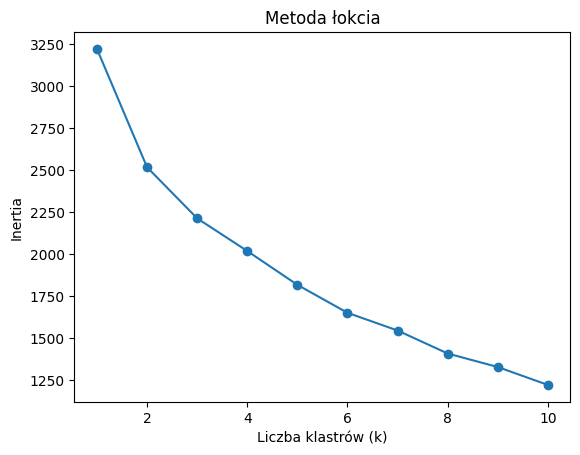

In [5]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("Inertia")
plt.title("Metoda łokcia")
plt.show()

In [6]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.227
k=3, silhouette=0.188
k=4, silhouette=0.181
k=5, silhouette=0.185
k=6, silhouette=0.186
k=7, silhouette=0.184
k=8, silhouette=0.194
k=9, silhouette=0.158
k=10, silhouette=0.187


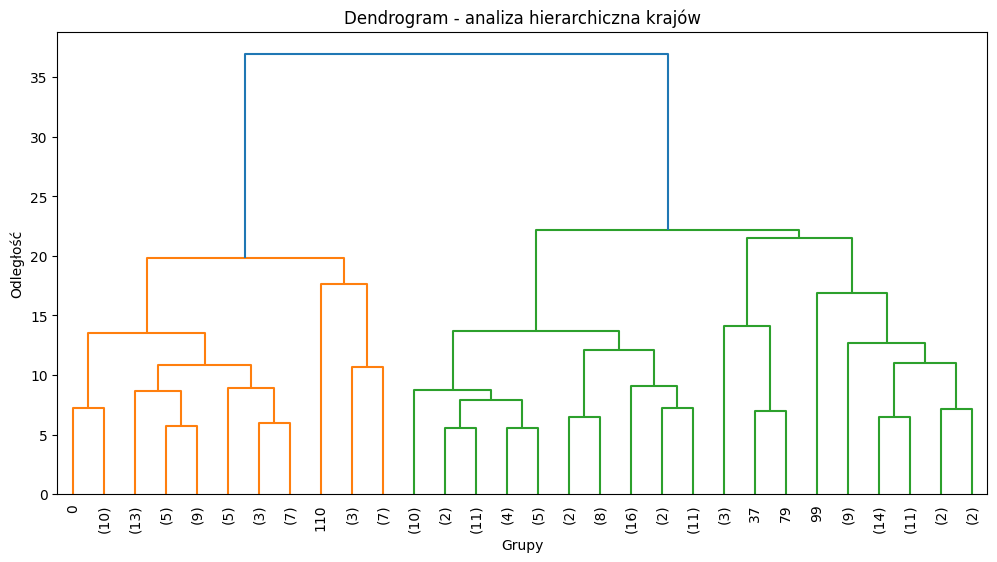

In [7]:
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Dendrogram - analiza hierarchiczna krajów")
plt.xlabel("Grupy")
plt.ylabel("Odległość")
plt.show()

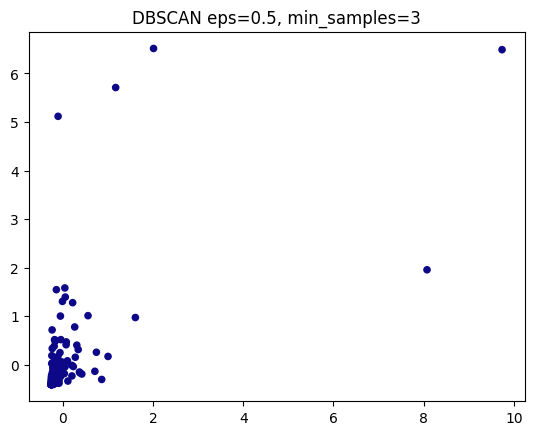

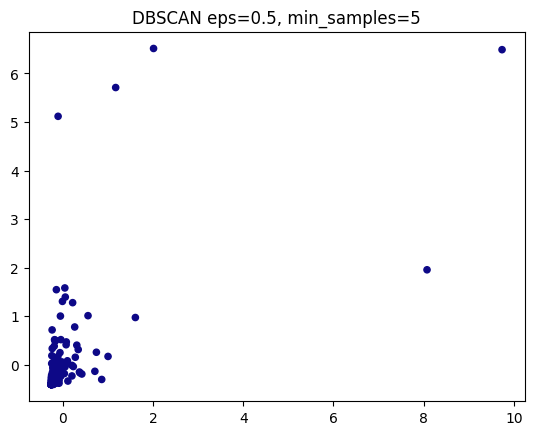

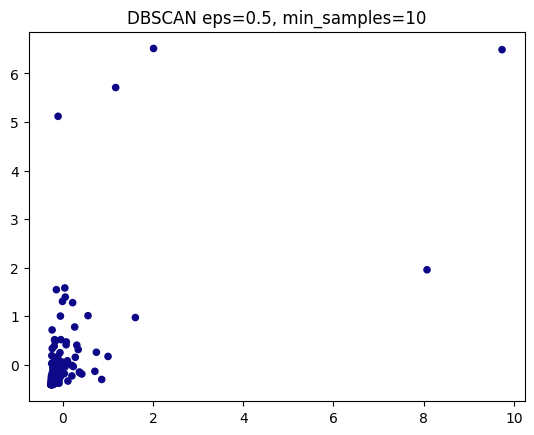

eps=1.0, min_samples=3, silhouette=-0.043


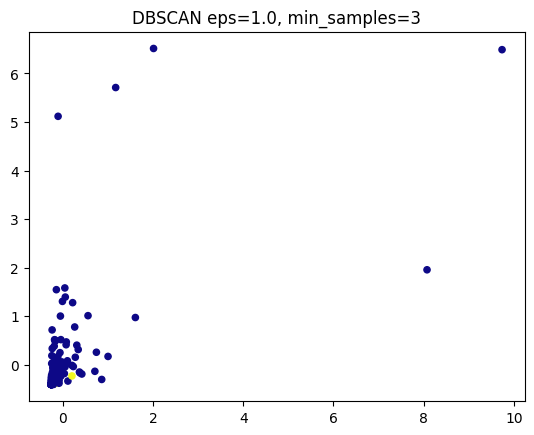

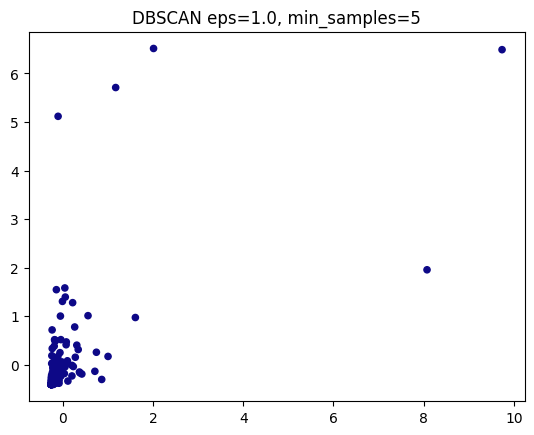

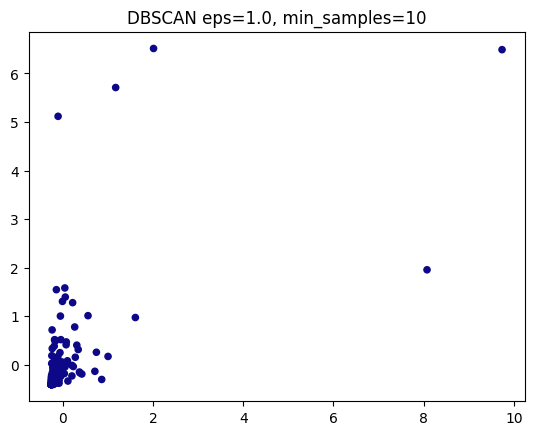

eps=1.5, min_samples=3, silhouette=-0.257


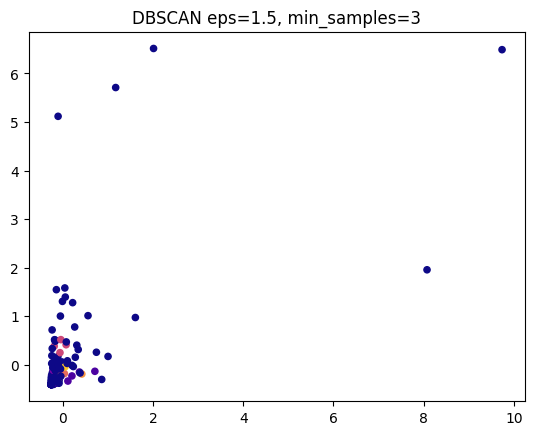

eps=1.5, min_samples=5, silhouette=-0.001


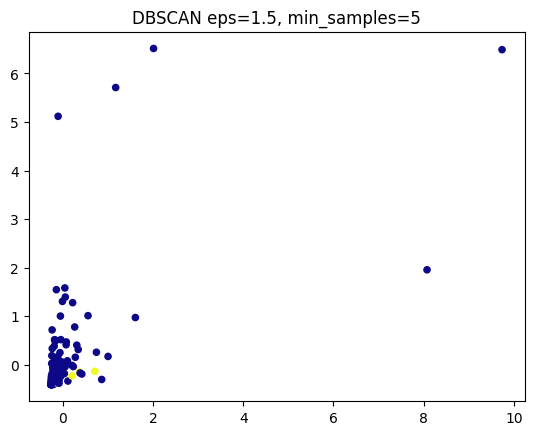

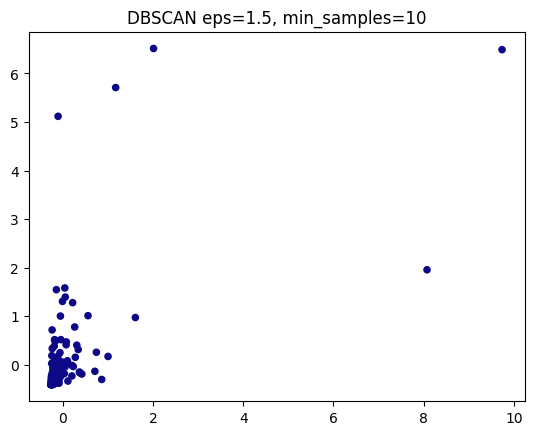

eps=2.0, min_samples=3, silhouette=0.106


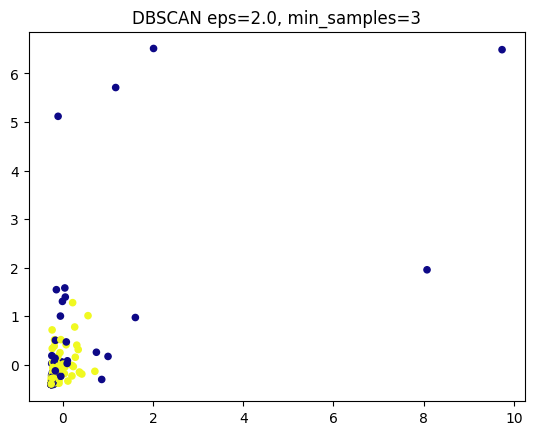

eps=2.0, min_samples=5, silhouette=0.053


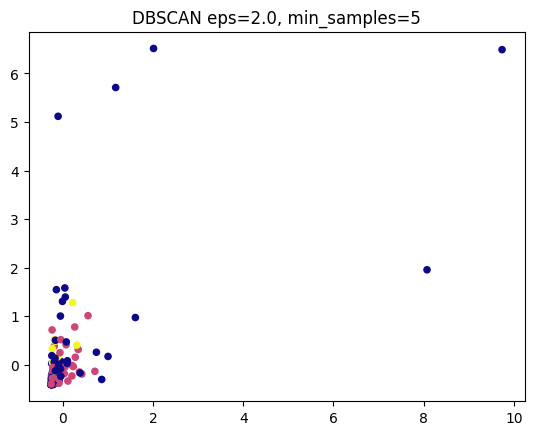

eps=2.0, min_samples=10, silhouette=-0.084


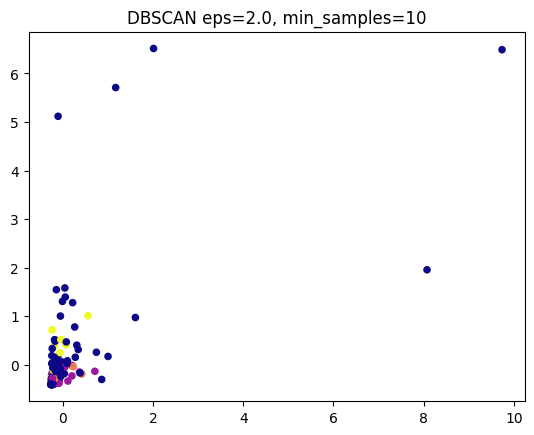

In [8]:
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        # ignore 1 klastra lub same szumy
        if len(set(labels)) > 1:
            try:
                score = silhouette_score(X, labels)
                print(f"eps={eps}, min_samples={ms}, silhouette={score:.3f}")
            except:
                pass

        plt.figure()
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=20)
        plt.title(f"DBSCAN eps={eps}, min_samples={ms}")
        plt.show()

Silhouette Agglomerative: 0.17635713090616523


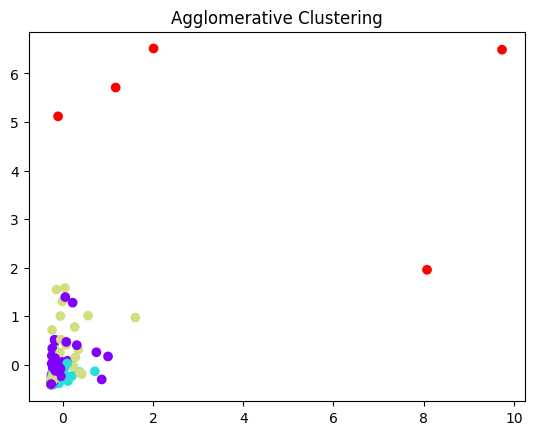

In [9]:
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X)

print("Silhouette Agglomerative:", silhouette_score(X, labels_agg))

plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='rainbow')
plt.title("Agglomerative Clustering")
plt.show()

In [14]:
# KMEANS
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
labels_km = kmeans.fit_predict(X)

# DBSCAN 
db = DBSCAN(eps=2.5, min_samples=5)
labels_db = db.fit_predict(X)

if len(set(labels_db)) <= 1:
    db = DBSCAN(eps=3.0, min_samples=4)
    labels_db = db.fit_predict(X)

# AGGLOMERATIVE
agg = AgglomerativeClustering(n_clusters=4)
labels_ag = agg.fit_predict(X)


# ocena
def evaluate(name, X, labels):
    print(f"\n{name}")

    print("silhouette:", round(silhouette_score(X, labels), 3))
    print("calinski_harabasz:", round(calinski_harabasz_score(X, labels), 3))
    print("davies_bouldin:", round(davies_bouldin_score(X, labels), 3))

# wyniki
evaluate("KMeans", X, labels_km)
evaluate("DBSCAN", X, labels_db)
evaluate("Agglomerative", X, labels_ag)


KMeans
silhouette: 0.181
calinski_harabasz: 34.78
davies_bouldin: 1.74

DBSCAN
silhouette: 0.242
calinski_harabasz: 4.732
davies_bouldin: 5.414

Agglomerative
silhouette: 0.176
calinski_harabasz: 32.802
davies_bouldin: 1.583
